In [1]:
from data_loader import SegmentationDataset, SegmentationDataModule
from evaluation_functions import compute_miou
from perturbation_methods import *
import torch

In [2]:
# Load dataset

# ESA-PhiLab-Edge/OEOBench-Burnt_Area_Dataset dataset
root_dir = '/local/s3167445/data'
dm = SegmentationDataModule(root_dir, batch_size=2, num_workers=4, transform=None)
dm.setup(stage='test')  # load test dataset

# Detect input channels dynamically
sample_img, _ = dm.test_dataset[0]#val_dataset[0]
in_ch = sample_img.shape[0]  # CHW format
print("Detected input channels:", in_ch)

Detected input channels: 7


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

from torch.utils.data import DataLoader

temp_ds = dm.test_dataset
temp_loader = DataLoader(temp_ds, batch_size=2, num_workers=4)




cuda


In [4]:
from my_models.my_baseline_models import *
pynas = torch.jit.load('my_models/PNAS_NVIDIA_jetson_AGX_orin.pt', map_location=device)
pynas.to(device)
pynas.eval()

resnet = ResNet18UNet(in_channels=7, num_classes=4) 
resnet.to(device)  
resnet.eval()
state_dict = torch.load("my_models/not_pretrained_resnet.pt", map_location=device)
resnet.load_state_dict(state_dict)#, strict=False)


/local/s3167445/msc_venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<All keys matched successfully>

In [ ]:
def get_predictions_multi(models, dataloader, device="cpu"):
    """
    models: dict -> {"name": model}
    returns:
        preds_dict: {"name": tensor of predictions}
        confs_dict: {"name": tensor of confidences}
        labels: ground truth tensor
    """
    preds_dict = {name: [] for name in models}
    confs_dict = {name: [] for name in models}
    labels_all = []

    # Set all models to eval
    for model in models.values():
        model.eval()

    with torch.no_grad():
        for x, y in dataloader:
            x = x.float().to(device)

            if y.ndim == 4:
                y = torch.argmax(y, dim=1)
            y = y.long().to(device)

            labels_all.append(y.cpu())

            for name, model in models.items():
                logits = model(x)

                # Convert to probabilities
                probs = torch.softmax(logits, dim=1)

                # Get confidence + prediction
                confs, preds = torch.max(probs, dim=1)

                preds_dict[name].append(preds.cpu())
                confs_dict[name].append(confs.cpu())

    if len(labels_all) == 0:
        raise ValueError("Dataloader produced no batches!")

    # Concatenate everything
    preds_dict = {
        name: torch.cat(preds_list)
        for name, preds_list in preds_dict.items()
    }

    confs_dict = {
        name: torch.cat(confs_list)
        for name, confs_list in confs_dict.items()
    }

    labels = torch.cat(labels_all)

    return preds_dict, confs_dict, labels

import numpy as np

def compute_miou_per_sample(preds, labels, num_classes=4):
    miou_per_sample = []

    for pred, label in zip(preds, labels):
        ious = []

        for c in range(num_classes):
            pred_c = pred == c
            label_c = label == c

            intersection = np.logical_and(pred_c, label_c).sum()
            union = np.logical_or(pred_c, label_c).sum()

            if union > 0:
                ious.append(intersection / union)

        if len(ious) > 0:
            miou_per_sample.append(np.mean(ious))
        else:
            miou_per_sample.append(0)

    return np.array(miou_per_sample)

In [ ]:
def pgd_attack(model, images, masks, eps=0.03, alpha=0.01, iters=40):
    images = images.to(device)
    masks = masks.to(device)
    
    # Start with a random perturbation (standard PGD practice)
    adv_images = images + torch.empty_like(images).uniform_(-eps, eps)
    adv_images = torch.clamp(adv_images, 0, 1).detach()

    for i in range(iters):
        adv_images.requires_grad = True
        outputs = model(adv_images)
        
        # Loss for segmentation (CrossEntropy expects long targets for masks)
        loss = torch.nn.functional.cross_entropy(outputs, masks)
        
        # Backpropagate to get gradients w.r.t the image
        grad = torch.autograd.grad(loss, adv_images, retain_graph=False, create_graph=False)[0]

        # Update adversarial image
        adv_images = adv_images.detach() + alpha * grad.sign()
        
        # Projection step: Clamp to ensure we stay within epsilon-ball and valid pixel range
        delta = torch.clamp(adv_images - images, min=-eps, max=eps)
        adv_images = torch.clamp(images + delta, min=0, max=1).detach()
        
    return adv_images

def pgd_generator(dataloader, models, eps=0.03, alpha=0.01, iters=20, device="cpu"):
    """
    Generates adversarial examples using PGD. 
    Targeting the first model in the dict to create the attack (Transferability test).
    """
    # Use the first model in the dict as the 'source' for gradients
    target_model_name = list(models.keys())[0]
    model = models[target_model_name]
    model.eval()

    for x, y in dataloader:
        x = x.float().to(device)
        if y.ndim == 4: y = torch.argmax(y, dim=1)
        y = y.long().to(device)

        # Initial random start
        adv_x = x.clone().detach() + torch.empty_like(x).uniform_(-eps, eps)
        adv_x = torch.clamp(adv_x, 0, 1)

        for _ in range(iters):
            adv_x.requires_grad = True
            outputs = model(adv_x)
            loss = torch.nn.functional.cross_entropy(outputs, y)
            
            grad = torch.autograd.grad(loss, adv_x, retain_graph=False, create_graph=False)[0]
            
            adv_x = adv_x.detach() + alpha * grad.sign()
            delta = torch.clamp(adv_x - x, min=-eps, max=eps)
            adv_x = torch.clamp(x + delta, min=0, max=1).detach()
        
        yield adv_x.cpu(), y.cpu()

In [9]:
# Setup models dictionary
from evaluation_functions import *
models = {
    "PNAS": pynas,
    "ResNet18": resnet
}

# 1. Get Reference (Clean) Predictions
print("Evaluating Baseline (Clean)...")
ref_preds_dict, ref_confs_dict, ref_labels = get_predictions_multi(models, temp_loader, device)

# 2. Define PGD Hyperparameters
eps_levels = [0.01, 0.03, 0.05] # Different 'strengths' of attack
adv_results = {name: {metric: [] for metric in ["mIoU", "consistency", "ECE"]} for name in models}

print(f"\n--- Starting PGD Adversarial Evaluation ---")

for eps in eps_levels:
    print(f"\nEvaluating PGD Epsilon: {eps}")

    # Generate adversarial data (Attacking based on PNAS gradients)
    # This will test how well ResNet stands up to PNAS-generated attacks
    adv_data_gen = pgd_generator(temp_loader, models, eps=eps, device=device)
    
    # Convert generator to list for get_predictions_multi
    adv_perturbed_data = list(adv_data_gen)

    # Single forward pass for predictions on adversarial data
    adv_preds_dict, adv_confs_dict, adv_labels = get_predictions_multi(models, adv_perturbed_data, device)

    for name in models:
        preds = adv_preds_dict[name]
        ref_preds = ref_preds_dict[name]
        confs = adv_confs_dict[name]
        
        # Calculate Metrics
        miou = compute_my_miou_from_preds(preds, adv_labels, num_classes=4)
        consistency = prediction_consistency(ref_preds, preds)
        ece = compute_ece_from_preds_and_conf(preds, confs, adv_labels)

        print(f"[{name}] eps={eps} | mIoU: {miou:.4f} | Consistency: {consistency:.4f}")
        
        # Store (optional: add to your global results dict)
        adv_results[name]["mIoU"].append(miou)

Evaluating Baseline (Clean)...

--- Starting PGD Adversarial Evaluation ---

Evaluating PGD Epsilon: 0.01
[PNAS] eps=0.01 | mIoU: 0.7369 | Consistency: 0.9166
[ResNet18] eps=0.01 | mIoU: 0.6269 | Consistency: 0.8358

Evaluating PGD Epsilon: 0.03
[PNAS] eps=0.03 | mIoU: 0.2677 | Consistency: 0.5097
[ResNet18] eps=0.03 | mIoU: 0.3074 | Consistency: 0.5557

Evaluating PGD Epsilon: 0.05
[PNAS] eps=0.05 | mIoU: 0.2021 | Consistency: 0.4162
[ResNet18] eps=0.05 | mIoU: 0.2691 | Consistency: 0.4800


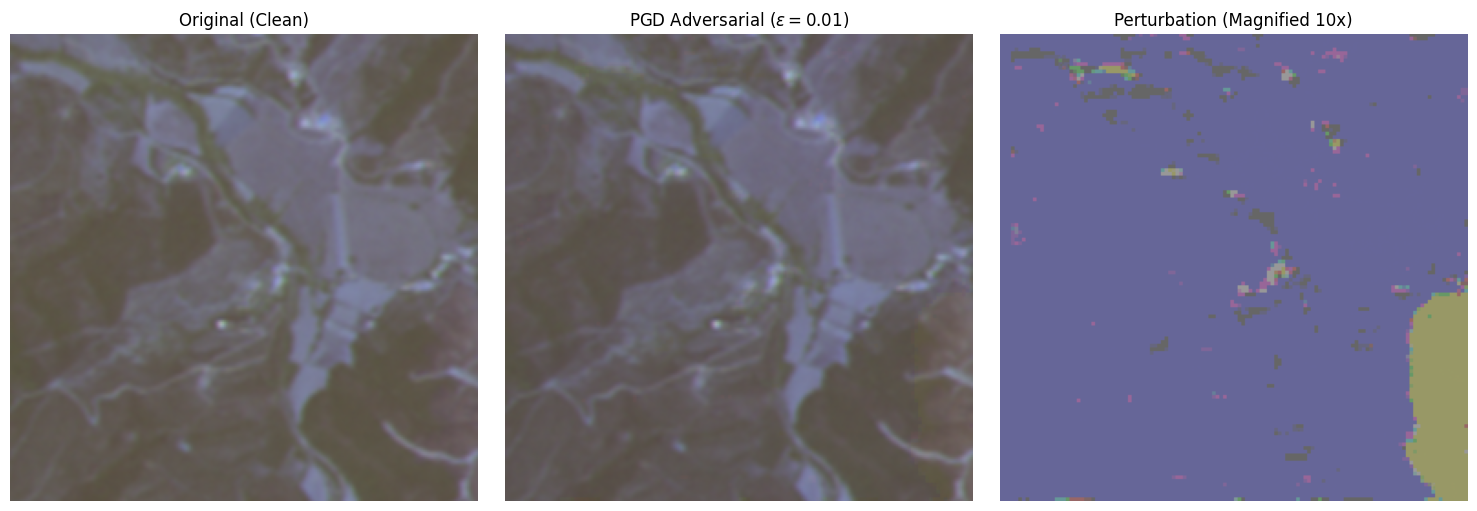

In [8]:
import matplotlib.pyplot as plt

# 1. Run a single PGD generation for epsilon 0.01
sample_eps = 0.01
# We just need one batch for visualization
viz_gen = pgd_generator(temp_loader, models, eps=sample_eps, iters=40, device=device)
adv_batch, labels_batch = next(viz_gen)

# 2. Get the original clean batch for comparison
clean_batch, _ = next(iter(temp_loader))

# 3. Pick the first image in the batch
# Assuming indices [0, 1, 2] correspond to your RGB bands
idx = 0
clean_img = clean_batch[idx].permute(1, 2, 0).cpu().numpy()[:, :, :3]
adv_img = adv_batch[idx].permute(1, 2, 0).cpu().numpy()[:, :, :3]

# Calculate the difference (magnified to see the attack pattern)
noise = adv_img - clean_img

# 4. Plotting
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(clean_img)
ax[0].set_title("Original (Clean)")
ax[0].axis("off")

ax[1].imshow(adv_img)
ax[1].set_title(f"PGD Adversarial ($\epsilon={sample_eps}$)")
ax[1].axis("off")

# We multiply noise by a factor (e.g., 10x or 50x) so you can actually see the gradient sign pixels
ax[2].imshow(0.5 + (noise * 10)) 
ax[2].set_title("Perturbation (Magnified 10x)")
ax[2].axis("off")

plt.tight_layout()
plt.show()